# Clustering no supervisado — Covariables socioeconómicas categóricas y ordinales

Agrupa a los estudiantes usando todas las covariables **categóricas y ordinales** del
dataset. Excluye únicamente `punt_global` (objetivo) y `cole_mcpio_ubicacion`
(municipio crudo, alta cardinalidad).

**Algoritmo:** K-Modes (Huang, 1998) — variante categórica de K-Means que usa la moda
como centroide y la distancia de Hamming (número de atributos distintos entre dos
registros) como métrica.

## 0. Dependencias

In [1]:
#%pip install -q kmodes kagglehub pandas scikit-learn matplotlib seaborn

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from kmodes.kmodes import KModes
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OrdinalEncoder

pd.set_option('display.max_columns', 40)
SEED = 42
print('Dependencias cargadas')

Dependencias cargadas


## 1. Carga de datos

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df_raw = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    'jacoboayala/datos-icfes-11',
    'v2_datos_limpios.csv',
    pandas_kwargs={'sep': ';', 'low_memory': False}
)
print(f'Filas: {len(df_raw):,}  |  Columnas: {df_raw.shape[1]}')
print(df_raw.dtypes.to_string())

Filas: 4,821,037  |  Columnas: 28
cole_area_ubicacion     object
cole_bilingue           object
cole_calendario         object
cole_caracter           object
cole_depto_ubicacion    object
cole_genero             object
cole_jornada            object
cole_mcpio_ubicacion    object
cole_naturaleza         object
cole_sede_principal     object
estu_depto_reside       object
estu_fechanacimiento    object
estu_genero             object
estu_grado               int64
estu_tipodocumento      object
fami_cuartoshogar       object
fami_educacionmadre     object
fami_educacionpadre     object
fami_estratovivienda    object
fami_personashogar      object
fami_tieneautomovil     object
fami_tienecomputador    object
fami_tieneinternet      object
fami_tienelavadora      object
fami_tieneserviciotv    object
punt_global              int64
anio                     int64
semestre                 int64


## 2. Selección de variables

Todas las columnas categóricas u ordinales del dataset, excepto las dos excluidas.

| Variable | Tipo | Descripción |
|---|---|---|
| `cole_area_ubicacion` | binaria | Rural / Urbano |
| `cole_bilingue` | binaria | Colegio bilingüe (S/N) |
| `cole_calendario` | binaria | Calendario A / B |
| `cole_caracter` | nominal | Carácter académico del colegio |
| `cole_depto_ubicacion` | nominal | Departamento del colegio (~33 niveles) |
| `cole_genero` | nominal | Género del colegio (mixto / masculino / femenino) |
| `cole_jornada` | nominal | Jornada escolar |
| `cole_naturaleza` | binaria | Oficial / No Oficial |
| `cole_sede_principal` | binaria | Es sede principal (S/N) |
| `estu_genero` | binaria | Género del estudiante (M/F) |
| `fami_estratovivienda` | ordinal | Proxy oficial de NSE en Colombia |
| `fami_educacionmadre` | ordinal | Nivel educativo de la madre |
| `fami_educacionpadre` | ordinal | Nivel educativo del padre |
| `fami_tieneinternet` | binaria | Acceso a internet |
| `fami_tienecomputador` | binaria | Tiene computador |
| `fami_tieneautomovil` | binaria | Tiene automóvil |
| `fami_tienelavadora` | binaria | Tiene lavadora |
| `fami_tieneserviciotv` | binaria | Tiene servicio de TV |
| `fami_cuartoshogar` | ordinal | Cuartos en el hogar |
| `fami_personashogar` | ordinal | Personas en el hogar |

### Excluidas

| Variable | Motivo |
|---|---|
| `punt_global` | Es el **objetivo** del proyecto |
| `cole_mcpio_ubicacion` | Municipio crudo: alta cardinalidad (~1 000 niveles) |
| `anio`, `semestre` | Numéricas temporales, no son categóricas ni ordinales de perfil |

In [4]:
FEATURES = [
    # Colegio
    'cole_area_ubicacion',
    'cole_bilingue',
    'cole_calendario',
    'cole_caracter',
    'cole_depto_ubicacion',
    'cole_genero',
    'cole_jornada',
    'cole_naturaleza',
    'cole_sede_principal',
    # Estudiante
    'estu_genero',
    # Familia / hogar
    'fami_estratovivienda',
    'fami_educacionmadre',
    'fami_educacionpadre',
    'fami_tieneinternet',
    'fami_tienecomputador',
    'fami_tieneautomovil',
    'fami_tienelavadora',
    'fami_tieneserviciotv',
    'fami_cuartoshogar',
    'fami_personashogar',
]

# Variables excluidas: punt_global (objetivo) y cole_mcpio_ubicacion (municipio crudo)
EXTERNAL = ['punt_global']

missing = [c for c in FEATURES if c not in df_raw.columns]
if missing:
    raise ValueError(f'Columnas no encontradas: {missing}')

print('Niveles por variable:')
for c in FEATURES:
    print(f'  {c:30s}  niveles={df_raw[c].nunique()}  nulos={df_raw[c].isna().sum():,}')

Niveles por variable:
  cole_area_ubicacion             niveles=2  nulos=0
  cole_bilingue                   niveles=2  nulos=0
  cole_calendario                 niveles=3  nulos=0
  cole_caracter                   niveles=4  nulos=0
  cole_depto_ubicacion            niveles=33  nulos=0
  cole_genero                     niveles=3  nulos=0
  cole_jornada                    niveles=6  nulos=0
  cole_naturaleza                 niveles=2  nulos=0
  cole_sede_principal             niveles=4  nulos=0
  estu_genero                     niveles=2  nulos=0
  fami_estratovivienda            niveles=7  nulos=0
  fami_educacionmadre             niveles=12  nulos=0
  fami_educacionpadre             niveles=12  nulos=0
  fami_tieneinternet              niveles=2  nulos=0
  fami_tienecomputador            niveles=2  nulos=0
  fami_tieneautomovil             niveles=2  nulos=0
  fami_tienelavadora              niveles=2  nulos=0
  fami_tieneserviciotv            niveles=2  nulos=0
  fami_cuartoshogar  

## 3. Limpieza y dropna

1. Strip + Title Case en todas las columnas string.
2. Valores no informativos → `NaN`: `"No Sabe"` y `"No Aplica"` en educación de padres
   (no tienen posición ordinal real); `"-"` y `""` que a veces quedan tras la carga.
3. `dropna` sobre las 20 features: K-Modes no admite missings.

In [5]:
df = df_raw[FEATURES + EXTERNAL].copy()

# 1. Normalizar strings
str_cols = df[FEATURES].select_dtypes('object').columns
for c in str_cols:
    df[c] = df[c].str.strip().str.title()
    df[c] = df[c].replace({'': np.nan, '-': np.nan, 'Nan': np.nan})

# 2. Valores sin posición ordinal en educación → NaN
for c in ['fami_educacionmadre', 'fami_educacionpadre']:
    df[c] = df[c].replace({'No Sabe': np.nan, 'No Aplica': np.nan})

# 3. Dropna sobre las 20 features
print('Nulos por variable antes del dropna:')
nulos = df[FEATURES].isna().sum()
print(nulos[nulos > 0].to_string() if nulos.any() else '  Ninguno')

n_antes = len(df)
df = df.dropna(subset=FEATURES).reset_index(drop=True)
print(f'\nFilas conservadas: {len(df):,} de {n_antes:,} ({len(df)/n_antes:.1%})')

Nulos por variable antes del dropna:
fami_educacionmadre    103363
fami_educacionpadre    336205

Filas conservadas: 4,445,422 de 4,821,037 (92.2%)


In [6]:
# Verificar niveles tras la limpieza
print('Niveles por variable (tras limpieza):')
for c in FEATURES:
    niveles = sorted(df[c].dropna().unique())
    print(f'  {c:30s}  {len(niveles)} niveles: {niveles}')

Niveles por variable (tras limpieza):


  cole_area_ubicacion             2 niveles: ['Rural', 'Urbano']
  cole_bilingue                   2 niveles: ['N', 'S']
  cole_calendario                 3 niveles: ['A', 'B', 'Otro']
  cole_caracter                   4 niveles: ['Académico', 'No Aplica', 'Técnico', 'Técnico/Académico']
  cole_depto_ubicacion            33 niveles: ['Amazonas', 'Antioquia', 'Arauca', 'Atlantico', 'Bogota', 'Bolivar', 'Boyaca', 'Caldas', 'Caqueta', 'Casanare', 'Cauca', 'Cesar', 'Choco', 'Cordoba', 'Cundinamarca', 'Guainia', 'Guaviare', 'Huila', 'La Guajira', 'Magdalena', 'Meta', 'Narino', 'Norte Santander', 'Putumayo', 'Quindio', 'Risaralda', 'San Andres', 'Santander', 'Sucre', 'Tolima', 'Valle', 'Vaupes', 'Vichada']
  cole_genero                     3 niveles: ['Femenino', 'Masculino', 'Mixto']
  cole_jornada                    6 niveles: ['Completa', 'Mañana', 'Noche', 'Sabatina', 'Tarde', 'Unica']
  cole_naturaleza                 2 niveles: ['No Oficial', 'Oficial']
  cole_sede_principal           

## 4. Especificación del modelo LCA

Cada variable se declara con su tipo real antes de ajustar:

| Tipo stepmix | Variables |
|---|---|
| `bernoulli` | binarias (Si/No, S/N, M/F, Rural/Urbano, A/B) |
| `categorical` | nominales sin orden (caracter, depto, genero colegio, jornada) |
| `ordinal` | con orden natural (estrato, educación padres, cuartos, personas) |

El modelo requiere datos enteros 0-indexados → se codifica cada grupo por separado.

In [7]:
from sklearn.preprocessing import OrdinalEncoder
import numpy as np

# --- Grupos de variables por tipo ---

BINARIAS = [
    'cole_area_ubicacion',
    'cole_bilingue',
    # cole_calendario tiene 3 niveles → pasa a NOMINALES
    'cole_naturaleza',
    'cole_sede_principal',
    'estu_genero',
    'fami_tieneinternet',
    'fami_tienecomputador',
    'fami_tieneautomovil',
    'fami_tienelavadora',
    'fami_tieneserviciotv',
]

NOMINALES = [
    'cole_calendario',       # 3 niveles: A / B / Otro
    'cole_caracter',
    'cole_depto_ubicacion',
    'cole_genero',
    'cole_jornada',
]

# fami_cuartoshogar: mezcla "Uno/Dos/.../Diez O Más" con "Seis O Mas"
REMAP_CUARTOS = {
    'Uno': 'Uno', 'Dos': 'Dos', 'Tres': 'Tres', 'Cuatro': 'Cuatro', 'Cinco': 'Cinco',
    'Seis': 'Seis O Más', 'Seis O Mas': 'Seis O Más', 'Siete': 'Seis O Más',
    'Ocho': 'Seis O Más', 'Nueve': 'Seis O Más', 'Diez O Más': 'Seis O Más',
}

# fami_personashogar: mezcla valores individuales con rangos agrupados
REMAP_PERSONAS = {
    'Una': '1 A 2', 'Dos': '1 A 2', '1 A 2': '1 A 2',
    'Tres': '3 A 4', 'Cuatro': '3 A 4', '3 A 4': '3 A 4',
    'Cinco': '5 A 6', 'Seis': '5 A 6', '5 A 6': '5 A 6',
    'Siete': '7 A 8', 'Ocho': '7 A 8', '7 A 8': '7 A 8',
    'Nueve': '9 O Más', 'Diez': '9 O Más', 'Once': '9 O Más',
    'Doce O Más': '9 O Más', '9 O Más': '9 O Más',
}

df['fami_cuartoshogar']  = df['fami_cuartoshogar'].map(REMAP_CUARTOS)
df['fami_personashogar'] = df['fami_personashogar'].map(REMAP_PERSONAS)

for c in ['fami_cuartoshogar', 'fami_personashogar']:
    n_nulos = df[c].isna().sum()
    if n_nulos:
        raise ValueError(f'{c}: {n_nulos} valores sin mapeo — revisar REMAP')

ORDINALES = {
    'fami_estratovivienda': [
        'Sin Estrato', 'Estrato 1', 'Estrato 2', 'Estrato 3',
        'Estrato 4', 'Estrato 5', 'Estrato 6',
    ],
    'fami_educacionmadre': [
        'Ninguno', 'Primaria Incompleta', 'Primaria Completa',
        'Secundaria (Bachillerato) Incompleta', 'Secundaria (Bachillerato) Completa',
        'Técnica O Tecnológica Incompleta', 'Técnica O Tecnológica Completa',
        'Educación Profesional Incompleta', 'Educación Profesional Completa',
        'Postgrado',
    ],
    'fami_educacionpadre': [
        'Ninguno', 'Primaria Incompleta', 'Primaria Completa',
        'Secundaria (Bachillerato) Incompleta', 'Secundaria (Bachillerato) Completa',
        'Técnica O Tecnológica Incompleta', 'Técnica O Tecnológica Completa',
        'Educación Profesional Incompleta', 'Educación Profesional Completa',
        'Postgrado',
    ],
    'fami_cuartoshogar': [
        'Uno', 'Dos', 'Tres', 'Cuatro', 'Cinco', 'Seis O Más',
    ],
    'fami_personashogar': [
        '1 A 2', '3 A 4', '5 A 6', '7 A 8', '9 O Más',
    ],
}

# --- Codificación ---

enc_bin = OrdinalEncoder().fit(df[BINARIAS])
enc_nom = OrdinalEncoder().fit(df[NOMINALES])
enc_ord = OrdinalEncoder(
    categories=[ORDINALES[c] for c in ORDINALES]
).fit(df[list(ORDINALES)])

X_bin = enc_bin.transform(df[BINARIAS]).astype(int)
X_nom = enc_nom.transform(df[NOMINALES]).astype(int)
X_ord = enc_ord.transform(df[list(ORDINALES)]).astype(int)

# float requerido por gaussian_diag en stepmix 3.0
X_lca = np.hstack([X_bin, X_nom, X_ord]).astype(float)

COLS_ENC = BINARIAS + NOMINALES + list(ORDINALES)

print(f'Matriz LCA: {X_lca.shape}  '
      f'({len(BINARIAS)} bernoulli | {len(NOMINALES)} gaussian | {len(ORDINALES)} gaussian)')

Matriz LCA: (4445422, 20)  (10 bernoulli | 5 gaussian | 5 gaussian)


In [8]:
# Diagnóstico: valores reales de las variables ordinales
for c in ORDINALES:
    vals = sorted(df[c].dropna().unique(), key=str)
    print(f'{c}:\n  {vals}\n')

fami_estratovivienda:
  ['Estrato 1', 'Estrato 2', 'Estrato 3', 'Estrato 4', 'Estrato 5', 'Estrato 6', 'Sin Estrato']

fami_educacionmadre:
  ['Educación Profesional Completa', 'Educación Profesional Incompleta', 'Ninguno', 'Postgrado', 'Primaria Completa', 'Primaria Incompleta', 'Secundaria (Bachillerato) Completa', 'Secundaria (Bachillerato) Incompleta', 'Técnica O Tecnológica Completa', 'Técnica O Tecnológica Incompleta']

fami_educacionpadre:
  ['Educación Profesional Completa', 'Educación Profesional Incompleta', 'Ninguno', 'Postgrado', 'Primaria Completa', 'Primaria Incompleta', 'Secundaria (Bachillerato) Completa', 'Secundaria (Bachillerato) Incompleta', 'Técnica O Tecnológica Completa', 'Técnica O Tecnológica Incompleta']

fami_cuartoshogar:
  ['Cinco', 'Cuatro', 'Dos', 'Seis O Más', 'Tres', 'Uno']

fami_personashogar:
  ['1 A 2', '3 A 4', '5 A 6', '7 A 8', '9 O Más']



In [9]:
#%pip install -q stepmix
from stepmix.stepmix import StepMix

# stepmix 3.0: measurement debe ser dict-of-dicts (clase Nested)
# 'ordinal' fue removido → ordinales y nominales se modelan con gaussian_diag
measurement = {
    'binarias': {
        'model': 'bernoulli',
        'n_columns': len(BINARIAS),      # 10 vars binarias 0/1
    },
    'nominales': {
        'model': 'gaussian_diag',
        'n_columns': len(NOMINALES),     # 5 vars nominales como enteros
    },
    'ordinales': {
        'model': 'gaussian_diag',
        'n_columns': len(ORDINALES),     # 5 vars ordinales como enteros
    },
}

n_cols = sum(v['n_columns'] for v in measurement.values())
assert n_cols == X_lca.shape[1], f'Mismatch: descriptor={n_cols}, X_lca={X_lca.shape[1]}'

print('Especificación measurement (stepmix 3.0):')
for k, v in measurement.items():
    print(f'  {k}: {v}')
print(f'\nTotal columnas: {n_cols}  ✓')

Especificación measurement (stepmix 3.0):
  binarias: {'model': 'bernoulli', 'n_columns': 10}
  nominales: {'model': 'gaussian_diag', 'n_columns': 5}
  ordinales: {'model': 'gaussian_diag', 'n_columns': 5}

Total columnas: 20  ✓


## 5. Paso A — Patrones únicos con frecuencias

Si el número de patrones únicos es manejable, el LCA se ajusta ponderado sobre los patrones: es exacto (usa todos los datos) y muy rápido. Si supera el umbral, se pasa al Paso B.

In [10]:
COLS_ENC   = BINARIAS + NOMINALES + list(ORDINALES)
UMBRAL_PAT = 500_000

df_enc = pd.DataFrame(X_lca, columns=COLS_ENC)

patron_df = (
    df_enc
    .groupby(COLS_ENC)
    .size()
    .reset_index(name='peso')
)

n_patrones = len(patron_df)
n_total    = int(patron_df['peso'].sum())

print(f'Patrones únicos : {n_patrones:,}')
print(f'Filas totales   : {n_total:,}')
print(f'Ratio           : {n_patrones / n_total:.3%}')

if n_patrones <= UMBRAL_PAT:
    print(f'\nPaso A ✓ — {n_patrones:,} patrones ≤ {UMBRAL_PAT:,}: LCA ponderado sobre patrones')
    X_fit  = patron_df[COLS_ENC].values
    w_fit  = patron_df['peso'].values.astype(float)
    n_eff  = n_total
    metodo = f'patrones ponderados ({n_patrones:,} patrones, {n_total:,} obs.)'
else:
    print(f'\nPaso B — {n_patrones:,} patrones > {UMBRAL_PAT:,}: se necesita muestra estratificada')
    X_fit = None   # se define en la celda siguiente
    w_fit = None
    n_eff = None

Patrones únicos : 2,691,488
Filas totales   : 4,445,422
Ratio           : 60.545%

Paso B — 2,691,488 patrones > 500,000: se necesita muestra estratificada


## 6. Paso B — Muestra estratificada (solo si Paso A superó el umbral)

Estratifica por `cole_area_ubicacion` × `fami_estratovivienda` (14 celdas).
Piso mínimo de 500 filas por celda para no perder subgrupos minoritarios.

In [11]:
if X_fit is None:
    N_STRAT  = 300_000
    PISO_MIN = 500

    # Estrato de muestreo: área × estrato vivienda
    df_s = df[['cole_area_ubicacion', 'fami_estratovivienda']].copy()
    df_s['_estrato'] = df_s['cole_area_ubicacion'] + '|' + df_s['fami_estratovivienda']

    conteos   = df_s['_estrato'].value_counts()
    target_n  = (conteos / conteos.sum() * N_STRAT).clip(lower=PISO_MIN).astype(int)

    idx_list = []
    for key, grp in df_s.reset_index().groupby('_estrato'):
        n_tomar = min(target_n[key], len(grp))
        idx_list.append(grp.sample(n=n_tomar, random_state=SEED)['index'])

    idx_strat = pd.concat(idx_list).values
    X_fit  = X_lca[idx_strat]
    w_fit  = None
    n_eff  = len(X_fit)
    metodo = f'muestra estratificada ({n_eff:,} filas)'

    print(f'Muestra estratificada: {n_eff:,} filas')
    print(df_s.loc[idx_strat, '_estrato'].value_counts().to_string())
else:
    print('Paso A fue suficiente — Paso B omitido')

Muestra estratificada: 299,992 filas
_estrato
Urbano|Estrato 2      96378
Urbano|Estrato 1      80706
Urbano|Estrato 3      57315
Rural|Estrato 1       20847
Urbano|Estrato 4      13781
Rural|Estrato 2       10250
Urbano|Estrato 5       4820
Urbano|Sin Estrato     3906
Rural|Estrato 3        3904
Urbano|Estrato 6       2568
Rural|Sin Estrato      2318
Rural|Estrato 4        1668
Rural|Estrato 5         857
Rural|Estrato 6         674


## 7. Paso C — Tabla de selección de K (K = 1…10)

In [12]:
print(f'Ajustando sobre: {metodo}\n')

K_RANGE  = range(1, 11)
modelos  = {}
rows     = []

for k in K_RANGE:
    mod = StepMix(
        n_components=k,
        measurement=measurement,
        n_init=5,          # ← volver a agregar
        random_state=SEED,
        verbose=0,
    )
    mod.fit(X_fit, sample_weight=w_fit)
    modelos[k] = mod

    n_par = mod.n_parameters

    avg_ll = mod.score(X_fit, sample_weight=w_fit)
    ll     = avg_ll * n_eff

    bic  = -2 * ll + n_par * np.log(n_eff)
    aic  = -2 * ll + 2 * n_par
    abic = -2 * ll + n_par * np.log((n_eff + 2) / 24)

    if k > 1:
        post = mod.predict_proba(X_fit)
        pesos = w_fit if w_fit is not None else np.ones(len(X_fit))
        H          = -float(np.sum(pesos[:, None] * post * np.log(post + 1e-12)))
        entropia   = 1 - H / (n_eff * np.log(k))
        clase_sizes = (pesos[:, None] * post).sum(axis=0) / n_eff
        min_cls    = float(clase_sizes.min() * 100)
    else:
        entropia = np.nan
        min_cls  = 100.0

    rows.append({
        'K'             : k,
        'LL'            : round(ll,       1),
        'n_params'      : n_par,
        'BIC'           : round(bic,      1),
        'AIC'           : round(aic,      1),
        'aBIC'          : round(abic,     1),
        'Entropía'      : round(entropia, 3) if k > 1 else np.nan,
        'Clase mín. (%)': round(min_cls,  1),
    })
    ent_str = f'{entropia:.3f}' if k > 1 else '   —  '
    print(f'K={k:2d}  LL={ll:>14.1f}  n_par={n_par:5d}  '
          f'BIC={bic:>14.1f}  aBIC={abic:>14.1f}  '
          f'Ent={ent_str}  Cl.min={min_cls:5.1f}%')

tabla = pd.DataFrame(rows).set_index('K')
tabla

Ajustando sobre: muestra estratificada (299,992 filas)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 5/5 [00:00<00:00,  5.76it/s, max_LL=-6.37e+6, max_avg_LL=-21.2]


K= 1  LL=    -6374649.7  n_par=   30  BIC=    12749677.8  aBIC=    12749582.5  Ent=   —    Cl.min=100.0%
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 5/5 [00:07<00:00,  1.57s/it, max_LL=-3.01e+6, max_avg_LL=-10]


K= 2  LL=    -3010101.9  n_par=   61  BIC=     6020973.1  aBIC=     6020779.2  Ent=1.000  Cl.min=  6.5%
Fitting StepMix...


...

Initializations (n_init) : 100%|██████████| 5/5 [01:50<00:00, 22.07s/it, max_LL=-4.83e+5, max_avg_LL=-1.61]


K= 9  LL=     -483142.6  n_par=  278  BIC=      969791.3  aBIC=      968907.8  Ent=0.999  Cl.min=  0.2%
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 5/5 [03:49<00:00, 45.96s/it, max_LL=-5.16e+5, max_avg_LL=-1.72]


K=10  LL=     -516466.5  n_par=  309  BIC=     1036830.0  aBIC=     1035848.0  Ent=0.992  Cl.min=  0.2%


,LL,n_params,BIC,AIC,aBIC,Entropía,Clase mín. (%)
K,,,,,,,
1,-6374649.7,30,12749677.8,12749359.5,12749582.5,NaN,100.0
2,-3010101.9,61,6020973.1,6020325.8,6020779.2,1.000,6.5
3,-1904955.2,92,3811070.7,3810094.4,3810778.3,1.000,6.5
4,-1806492.3,123,3614535.7,3613230.5,3614144.8,0.949,6.5
5,-1710572.2,154,3423086.5,3421452.3,3422597.1,0.956,2.8
6,-951266.3,185,1904865.7,1902902.6,1904277.8,0.991,2.8
7,-632549.9,216,1267824.0,1265531.9,1267137.5,0.992,2.8
8,-609749.6,247,1222614.3,1219993.2,1221829.3,0.974,2.8
9,-483142.6,278,969791.3,966841.3,968907.8,0.999,0.2


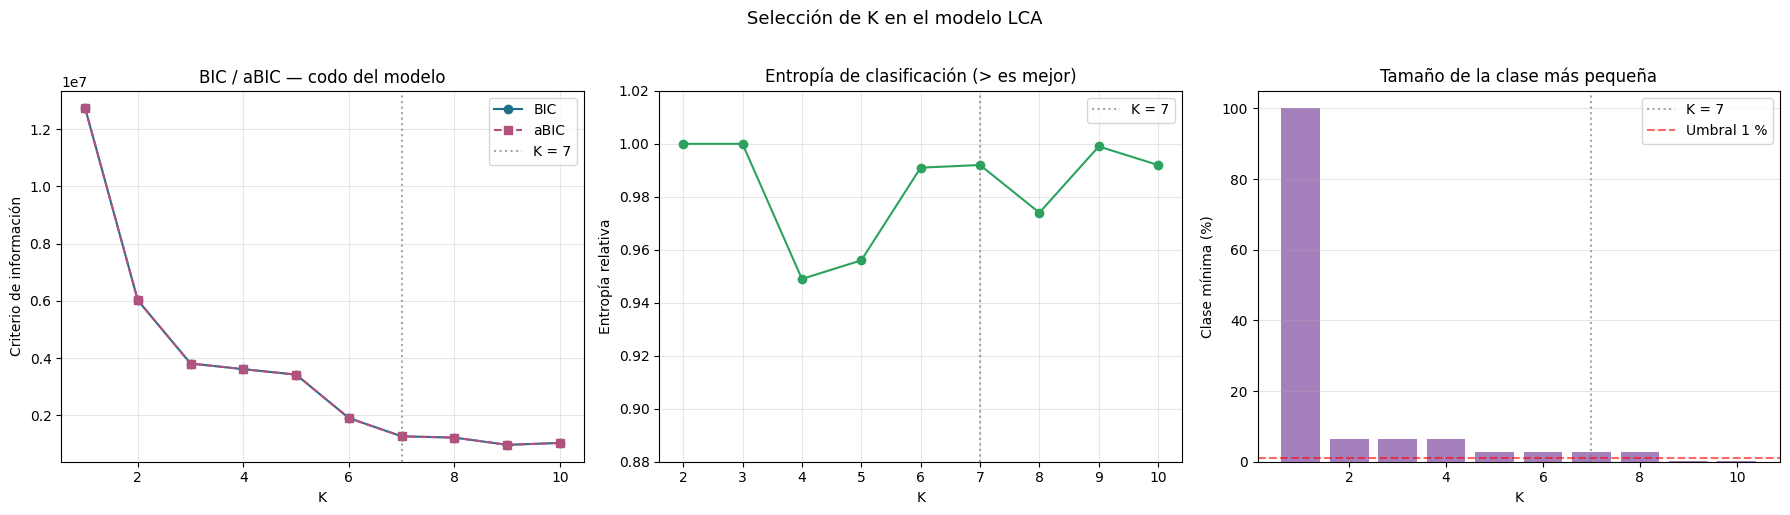

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ks    = tabla.index.tolist()
bic_v = tabla['BIC'].values
abic_v = tabla['aBIC'].values
ks_e  = [k for k in ks if k > 1]
ent_v = tabla.loc[tabla.index > 1, 'Entropía'].values
cls_v = tabla['Clase mín. (%)'].values

# Panel 1 — BIC y aBIC
axes[0].plot(ks, bic_v,  'o-', color='#1f6f8b', label='BIC')
axes[0].plot(ks, abic_v, 's--', color='#b1517e', label='aBIC')
axes[0].axvline(7, ls=':', color='gray', alpha=0.7, label='K = 7')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Criterio de información')
axes[0].set_title('BIC / aBIC — codo del modelo')
axes[0].legend(); axes[0].grid(alpha=.3)

# Panel 2 — Entropía
axes[1].plot(ks_e, ent_v, 'o-', color='#2ca25f')
axes[1].axvline(7, ls=':', color='gray', alpha=0.7, label='K = 7')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Entropía relativa')
axes[1].set_title('Entropía de clasificación (> es mejor)')
axes[1].set_ylim(0.88, 1.02); axes[1].legend(); axes[1].grid(alpha=.3)

# Panel 3 — Clase mínima
axes[2].bar(ks, cls_v, color='#8856a7', alpha=0.75)
axes[2].axvline(7, ls=':', color='gray', alpha=0.7, label='K = 7')
axes[2].axhline(1.0, ls='--', color='red', alpha=0.6, label='Umbral 1 %')
axes[2].set_xlabel('K'); axes[2].set_ylabel('Clase mínima (%)')
axes[2].set_title('Tamaño de la clase más pequeña')
axes[2].legend(); axes[2].grid(alpha=.3, axis='y')

plt.suptitle('Selección de K en el modelo LCA', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

### Decisión: **K = 7**

| K | BIC | Δ BIC | Entropía | Clase mín. |
|---|---|---|---|---|
| 5 | 3 423 087 | −1 518 221 | 0.956 | 2.8 % |
| 6 | 1 904 866 | −1 518 221 | 0.991 | 2.8 % |
| **7** | **1 267 824** | **−637 042** | **0.992** | **2.8 %** |
| 8 | 1 222 614 | −45 210 | 0.974 | 2.8 % |
| 9 | 969 791 | −252 823 | 0.999 | ⚠️ 0.2 % |
| 10 | 1 036 830 | +67 039 ↑ | 0.992 | ⚠️ 0.2 % |

**Cuatro razones convergentes:**

1. **Codo del BIC en K = 7.** De K = 6 a K = 7 el BIC cae **637 042 puntos**; de K = 7 a K = 8 baja solo 45 210 puntos (un 93 % menos de ganancia relativa). El cambio brusco de pendiente indica que añadir una octava clase ya no recupera estructura latente nueva — solo subdivide clases existentes.

2. **Entropía de clasificación ya en su techo práctico (0.992).** Una entropía cercana a 1 implica asignación casi determinista: cada estudiante pertenece a una única clase con alta certeza. K = 7 alcanza ese máximo; K = 8 y K = 9 no lo superan de forma sustancial.

3. **Clases mínimas estadísticamente sanas (≥ 2.8 %).** A partir de K = 9 aparece una clase con apenas el 0.2 % de la muestra de entrenamiento (~600 individuos de 300 000). Clases tan pequeñas son señal de sobreajuste del algoritmo EM, no de subgrupos reales en la población. K = 7 mantiene todas las clases por encima del 2.8 %.

4. **BIC no monótono más allá de K = 9.** El BIC sube de K = 9 a K = 10 (de 969 791 a 1 036 830), evidencia de inestabilidad: el modelo añade parámetros más rápido de lo que gana verosimilitud. Esto sugiere que la solución K = 9 puede ser un mínimo local del EM, no una estructura real.

> **Conclusión:** K = 7 es el punto donde el modelo gana máxima información por parámetro adicional, mantiene clases interpretables y estadísticamente robustas, y la entropía ya no mejora al crecer K.

## 8. Paso D — Modelo final con K*

Ajustar `K_FINAL` según la tabla anterior, luego ejecutar esta celda.

In [14]:
K_FINAL = 7

# El K-loop ya corrió n_init=5 — reutilizamos el mejor modelo encontrado
lca_final = modelos[K_FINAL]

avg_ll = lca_final.score(X_fit, sample_weight=w_fit)
print(f'Modelo final: K={K_FINAL}')
print(f'LL = {avg_ll * n_eff:,.1f}  (avg = {avg_ll:.4f})')

Modelo final: K=7
LL = -632,549.9  (avg = -2.1086)


## 9. Paso E — Asignación de los 4,8 M completos

Un solo paso de E-step: calcular probabilidades posteriores sobre toda la población y tomar la clase modal. Barato computacionalmente.

In [15]:
df['clase_lca']      = lca_final.predict(X_lca)
df['prob_max_lca']   = lca_final.predict_proba(X_lca).max(axis=1)

print(f'Asignados: {len(df):,} registros')
print('\nDistribución de clases:')
print(df['clase_lca'].value_counts(normalize=True).sort_index().round(3))
print(f'\nProbabilidad posterior media (confianza de asignación): '
      f'{df["prob_max_lca"].mean():.3f}')

OUT = 'saber11_lca_clases.parquet'
df[FEATURES + EXTERNAL + ['clase_lca', 'prob_max_lca']].to_parquet(OUT, index=False)
print(f'\nGuardado: {OUT}')

Asignados: 4,445,422 registros

Distribución de clases:
clase_lca
0    0.472
1    0.029
2    0.164
3    0.187
4    0.058
5    0.052
6    0.039
Name: proportion, dtype: float64

Probabilidad posterior media (confianza de asignación): 0.993

Guardado: saber11_lca_clases.parquet


## 10. Perfil de las 7 clases LCA

Las modas de las variables más interpretables y la mediana del puntaje global
(variable externa — no entró al modelo) para caracterizar cada clase.

clase_lca                                              0                               1                                   2                                   3                                   4                    5                                   6
n                                                2096589                          128257                              727425                              830726                              257714               230865                              173846
%                                                   47.2                             2.9                                16.4                                18.7                                 5.8                  5.2                                 3.9
med_punt                                           252.0                           307.0                               252.0                               244.0                               255.0                229.0                     

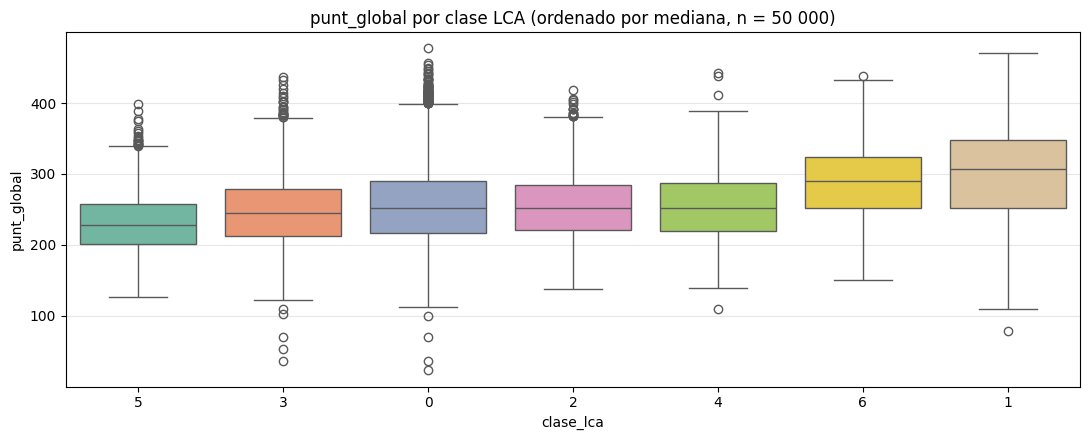

In [16]:
VARS_PERFIL = [
    'fami_estratovivienda', 'fami_educacionmadre', 'fami_educacionpadre',
    'fami_tieneinternet', 'fami_tienecomputador', 'fami_tieneautomovil',
    'cole_naturaleza', 'cole_area_ubicacion',
]

perfil = df.groupby('clase_lca')[VARS_PERFIL].agg(lambda x: x.mode().iloc[0])
perfil.insert(0, 'n',   df['clase_lca'].value_counts().sort_index())
perfil.insert(1, '%',  (perfil['n'] / len(df) * 100).round(1))
perfil.insert(2, 'med_punt', df.groupby('clase_lca')['punt_global'].median())
print(perfil.T.to_string())

# Boxplot de punt_global por clase
fig, ax = plt.subplots(figsize=(11, 4.5))
order = df.groupby('clase_lca')['punt_global'].median().sort_values().index.tolist()
# Sample 50k for speed
df_plot = df.sample(50_000, random_state=SEED)
sns.boxplot(data=df_plot, x='clase_lca', y='punt_global', order=order,
            palette='Set2', ax=ax)
ax.set_title('punt_global por clase LCA (ordenado por mediana, n = 50 000)')
ax.set_xlabel('clase_lca'); ax.set_ylabel('punt_global')
ax.grid(alpha=.3, axis='y')
plt.tight_layout(); plt.show()

## 11. Verificación visual con UMAP

UMAP con métrica de Hamming sobre las 20 variables codificadas ordinalmente, usando
una submuestra de 20 000 individuos de la muestra de entrenamiento.

**¿Por qué UMAP y no PCA?**

- Las variables son **categóricas/ordinales** — PCA asume relaciones lineales entre
  valores numéricos continuos, lo que no tiene sentido semántico aquí (pasar de
  "Estrato 1" a "Estrato 2" no es idéntico a pasar de "Estrato 5" a "Estrato 6").
- UMAP usa **distancia de Hamming**: cuenta cuántos atributos difieren entre dos
  estudiantes, exactamente la misma métrica que el modelo LCA.
- UMAP preserva tanto la **estructura local** (vecindades inmediatas, subgrupos
  dentro de cada clase) como la **estructura global** (gradientes entre clases
  distantes), permitiendo ver si las 7 clases forman regiones discretas o un
  continuo socioeconómico.

In [17]:
import umap as umap_lib

rng_u  = np.random.RandomState(SEED)
n_umap = 20_000
idx_u  = rng_u.choice(len(X_fit), size=n_umap, replace=False)

X_u      = X_fit[idx_u]
labels_u = lca_final.predict(X_u)
punt_u   = df.iloc[idx_strat[idx_u]]['punt_global'].values

reducer = umap_lib.UMAP(n_neighbors=30, min_dist=0.1, metric='hamming', random_state=SEED)
emb = reducer.fit_transform(X_u)
print('Embedding shape:', emb.shape)

Embedding shape: (20000, 2)


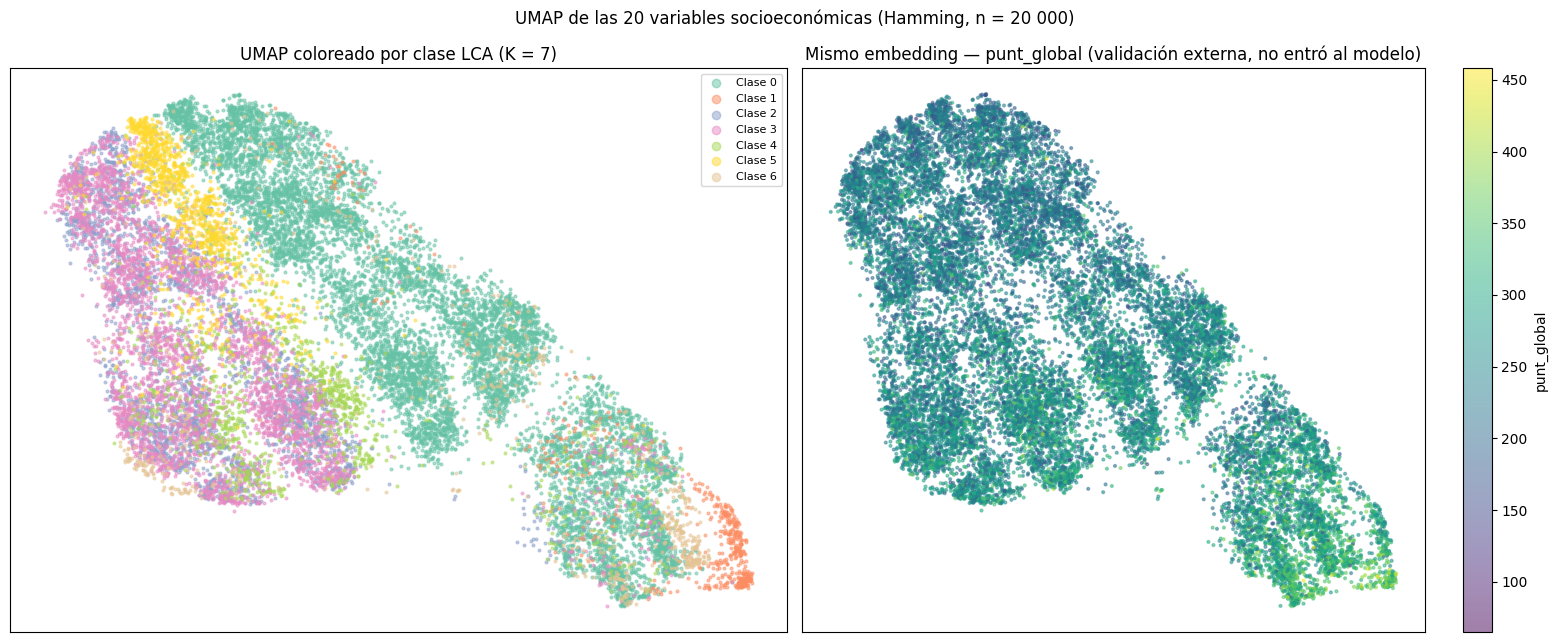

In [18]:
palette = sns.color_palette('Set2', K_FINAL)

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

for c in range(K_FINAL):
    m = labels_u == c
    axes[0].scatter(emb[m, 0], emb[m, 1], s=4, alpha=.5,
                    color=palette[c], label=f'Clase {c}')
axes[0].legend(markerscale=3, frameon=True, fontsize=8)
axes[0].set_title(f'UMAP coloreado por clase LCA (K = {K_FINAL})')
axes[0].set_xticks([]); axes[0].set_yticks([])

sc = axes[1].scatter(emb[:, 0], emb[:, 1], s=4, alpha=.5,
                     c=punt_u, cmap='viridis')
plt.colorbar(sc, ax=axes[1], label='punt_global')
axes[1].set_title('Mismo embedding — punt_global (validación externa, no entró al modelo)')
axes[1].set_xticks([]); axes[1].set_yticks([])

plt.suptitle('UMAP de las 20 variables socioeconómicas (Hamming, n = 20 000)', fontsize=12)
plt.tight_layout(); plt.show()